# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# Exercise 2 — Logistic Regression: Disease Susceptibility

**Scenario:** A medical logistic regression example (in the style of the DATAtab / numiqo
"Medical example logistic regression" calculator) investigating whether a person is
**susceptible to a disease (yes/no)** based on health/lifestyle predictors.

**Goal:** Predict `disease` (0 = not susceptible, 1 = susceptible) from `age`, `bmi`,
`blood_pressure`, `cholesterol`, and `smoker`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, accuracy_score)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Build a representative dataset

To replace this with the **real** DATAtab/numiqo example data: open the calculator link, copy
the data table shown in the app (there's a copy/export icon above the table), and paste it into
a DataFrame in place of the cell below — every subsequent cell will work unchanged as long as the
column names line up (or you rename them to match).


In [2]:
def generate_medical_data(n=300, seed=42):
    rng = np.random.default_rng(seed)

    age = rng.integers(20, 80, n)
    bmi = rng.normal(26, 4.5, n).clip(16, 45)
    blood_pressure = rng.normal(120, 15, n) + 0.25 * (age - 45)   # BP rises with age
    blood_pressure = blood_pressure.clip(85, 200)
    cholesterol = rng.normal(200, 30, n) + 0.4 * (bmi - 26)
    cholesterol = cholesterol.clip(120, 320)
    smoker = rng.binomial(1, 0.28, n)

    # True (unknown to the model) data-generating process
    z = (
        -9.0
        + 0.055 * age
        + 0.09 * bmi
        + 0.035 * (blood_pressure - 120)
        + 0.02 * (cholesterol - 200)
        + 0.9 * smoker
    )
    p = 1 / (1 + np.exp(-z))
    disease = rng.binomial(1, p)

    df = pd.DataFrame({
        "age": age,
        "bmi": bmi.round(1),
        "blood_pressure": blood_pressure.round(0).astype(int),
        "cholesterol": cholesterol.round(0).astype(int),
        "smoker": smoker,
        "disease": disease,
    })
    return df


df = generate_medical_data(300, seed=RANDOM_STATE)
print("Rows:", len(df), " | Disease prevalence:", round(df["disease"].mean(), 3))
df.head()


Rows: 300  | Disease prevalence: 0.08


,age,bmi,blood_pressure,cholesterol,smoker,disease
0,25,30.8,132,191,1,1
1,66,26.7,131,173,1,1
2,59,25.3,122,200,1,0
3,46,21.3,125,189,1,0
4,45,18.5,149,167,1,0


## 2. Explore the data

In [3]:
df.describe()


,age,bmi,blood_pressure,cholesterol,smoker,disease
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,49.446667,25.993000,120.046667,200.246667,0.286667,0.080000
std,16.354778,4.473346,16.085198,28.664111,0.452960,0.271746
min,20.000000,16.000000,85.000000,120.000000,0.000000,0.000000
25%,36.000000,22.900000,108.000000,183.750000,0.000000,0.000000
50%,49.000000,26.050000,121.000000,201.500000,0.000000,0.000000
75%,63.250000,28.900000,131.000000,218.000000,1.000000,0.000000
max,79.000000,39.100000,162.000000,293.000000,1.000000,1.000000


/tmp/ipykernel_682/3854825175.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No disease", "Disease"])
/tmp/ipykernel_682/3854825175.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No disease", "Disease"])
/tmp/ipykernel_682/3854825175.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No disease", "Disease"])
/tmp/ipykernel_682/3854825175.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No disease", "Disease"])


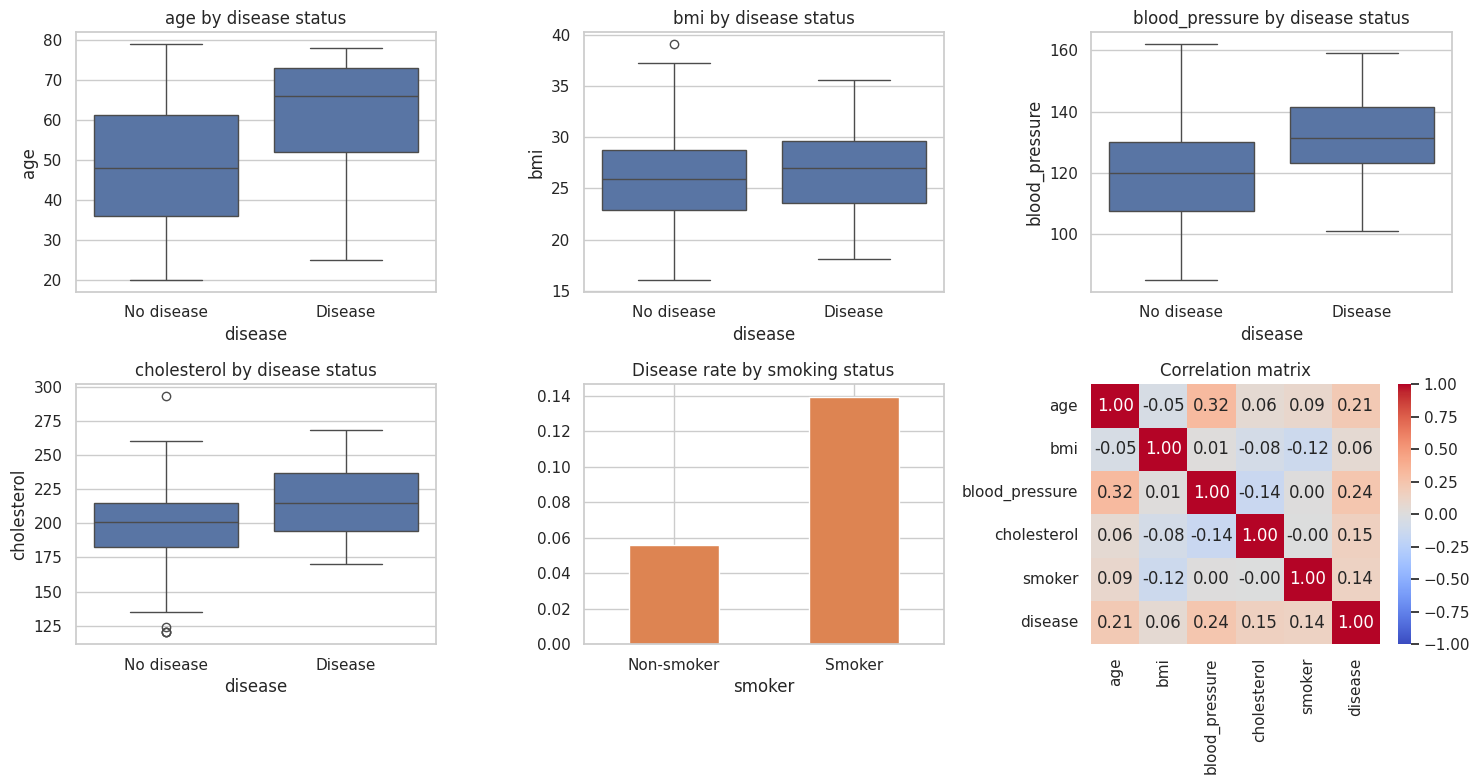

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat[:4], ["age", "bmi", "blood_pressure", "cholesterol"]):
    sns.boxplot(data=df, x="disease", y=col, ax=ax)
    ax.set_xticklabels(["No disease", "Disease"])
    ax.set_title(f"{col} by disease status")

smoker_rate = df.groupby("smoker")["disease"].mean()
smoker_rate.plot(kind="bar", ax=axes.flat[4], color="#DD8452")
axes.flat[4].set_xticklabels(["Non-smoker", "Smoker"], rotation=0)
axes.flat[4].set_title("Disease rate by smoking status")

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=axes.flat[5])
axes.flat[5].set_title("Correlation matrix")

plt.tight_layout()
plt.show()


## 3. Fit the logistic regression with `statsmodels`

In [5]:
logit_model = smf.logit(
    "disease ~ age + bmi + blood_pressure + cholesterol + smoker", data=df
).fit()
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.205698
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                disease   No. Observations:                  300
Model:                          Logit   Df Residuals:                      294
Method:                           MLE   Df Model:                            5
Date:                Wed, 29 Jul 2026   Pseudo R-squ.:                  0.2621
Time:                        09:16:32   Log-Likelihood:                -61.710
converged:                       True   LL-Null:                       -83.631
Covariance Type:            nonrobust   LLR p-value:                 2.493e-08
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -21.9428      4.030     -5.445      0.000     -29.841     -14.044
age              

In [6]:
odds_ratios = pd.DataFrame({
    "coef": logit_model.params,
    "OR": np.exp(logit_model.params),
    "2.5% CI (OR)": np.exp(logit_model.conf_int()[0]),
    "97.5% CI (OR)": np.exp(logit_model.conf_int()[1]),
    "p-value": logit_model.pvalues
})
odds_ratios


,coef,OR,2.5% CI (OR),97.5% CI (OR),p-value
Intercept,-21.942770,2.953766e-10,1.096732e-13,7.955211e-07,5.181652e-08
age,0.041428,1.042298e+00,1.005268e+00,1.080692e+00,2.478959e-02
bmi,0.103868,1.109454e+00,1.000443e+00,1.230342e+00,4.902597e-02
blood_pressure,0.059699,1.061516e+00,1.026793e+00,1.097414e+00,4.345214e-04
cholesterol,0.030498,1.030968e+00,1.012036e+00,1.050254e+00,1.258920e-03
smoker,1.520844,4.576084e+00,1.676233e+00,1.249262e+01,2.996928e-03


**Interpretation:** each odds ratio (OR) tells you how the odds of being susceptible to the
disease change with a one-unit increase in that predictor, holding the others constant. An OR
above 1 increases risk; below 1 decreases it. For `smoker` (a 0/1 variable), the OR is the
multiplicative change in odds for smokers vs. non-smokers.


## 4. Fit with `scikit-learn` and evaluate predictive performance

In [7]:
feature_cols = ["age", "bmi", "blood_pressure", "cholesterol", "smoker"]
X = df[feature_cols]
y = df["disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=["No disease", "Disease"]))


Accuracy: 0.933
ROC-AUC : 0.877

              precision    recall  f1-score   support

  No disease       0.93      1.00      0.97        69
     Disease       1.00      0.17      0.29         6

    accuracy                           0.93        75
   macro avg       0.97      0.58      0.63        75
weighted avg       0.94      0.93      0.91        75



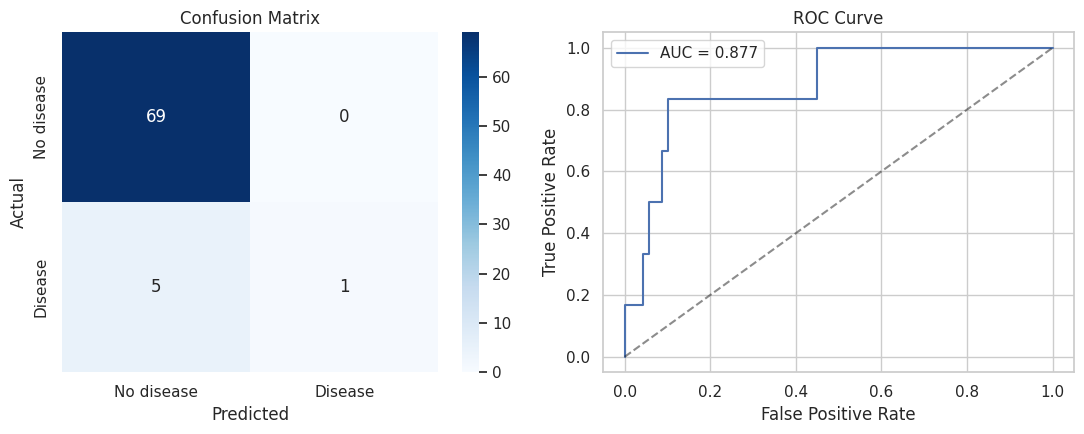

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No disease", "Disease"],
            yticklabels=["No disease", "Disease"], ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 5. Predict disease susceptibility for a new patient

In [9]:
new_patient = pd.DataFrame({
    "age": [58],
    "bmi": [31.2],
    "blood_pressure": [148],
    "cholesterol": [245],
    "smoker": [1],
})

new_patient_scaled = scaler.transform(new_patient[feature_cols])
prob_disease = clf.predict_proba(new_patient_scaled)[0, 1]
print(f"Predicted probability of disease susceptibility: {prob_disease:.1%}")


Predicted probability of disease susceptibility: 63.0%
